# RWPE — Fixed Architecture, Node-Encoding Runs (HI-Small)

- **Question:** does a random-walk positional encoding (RWPE, 16 values per account telling the network where the account sits in the graph) help, when the GNN architecture is held *exactly* fixed?
- **Knobs per run:** `operator` (gin / gat / pna / transformer), `mp` / `readout` edge features as in the operator notebooks, `node_enc` = `rwpe16` (`rwpe8` later, by the rule in `EXPERIMENTS.md` §1). RWPE only widens `node_proj` to (6 + 16) → 128; nothing else changes.
- **Everything shared** (model template, training loop, threshold selection, metrics, plots, saving) lives in `gnn_core.py`; this notebook only sets the run list and paths. All eight runs of stage 1 in one session, so the executed notebook holds every training log; each run is compared with the same configuration without RWPE in that operator's notebook.
- **Protocol:** threshold swept on validation each epoch, best-val-F1 checkpoint, test scored once; every metric on train / val / test. `invariant_params` must stay at the family value (GIN 67,587 · GATv2 67,585 · PNA 427,265 · Transformer 133,121).

## 0. Environment (Kaggle)

- Pinned PyTorch / PyG stack known to work on Kaggle GPU — do not change versions or order.
- Then clone (or pull) the public repo so the committed `gnn_core.py` is the one imported.

In [1]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 192.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 179.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 194.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 86.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 129.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys

REPO_URL = 'https://github.com/sandrokhizanishvili/gnn_for_fraudulent_patterns.git'
REPO_DIR = '/kaggle/working/gnn_for_fraudulent_patterns'
if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
!git -C {REPO_DIR} log -1 --oneline
sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/gnn_for_fraudulent_patterns'...
remote: Enumerating objects: 279, done.
remote: Counting objects: 100% (279/279), done.
remote: Compressing objects: 100% (237/237), done.
remote: Total 279 (delta 99), reused 216 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (279/279), 9.90 MiB | 11.97 MiB/s, done.
Resolving deltas: 100% (99/99), done.
279158f (HEAD -> main, origin/main, origin/HEAD) RWPE node encoding: rwpe_compute.py + RWPE_encoding.ipynb (k=8/16 per snapshot, self-loops dropped, checked against PyG AddRandomWalkPE); NODE_ENC knob in gnn_core.py (only node_proj widens); RWPE_fixed_architecture.ipynb with the 8 stage-1 configs; docs: best-of tables ranked by validation F1, §7.5 stub, Notion synced


## 1. Configuration

- The only cell that differs from the operator notebooks: `CONFIGS` lists `(operator, mp, readout, node_enc)` per run; all eight stage-1 runs are active (about 6.5 h on a T4).
- `RWPE_DIR`: the Kaggle dataset `hi-small-rwpe` (the six `Data/rwpe/rwpe_k{8,16}_{train,val,test}.pt` files), added as a second input next to `hi-small-gnn`.
- Runs land in `OUT_BASE/<OPERATOR>/<run>/`, mirroring `Outputs/RWPE/<FAMILY>/` in the repo (separate from the operator batches in `Outputs/<FAMILY>/`); the batch summary is `batch_summary_rwpe.csv` per family.

In [3]:
# runs of this batch — all eight stage-1 runs in one session, so this notebook holds every training log
CONFIGS = [
    dict(operator='gin', mp='base', readout='full', node_enc='rwpe16'),          # GIN-5 + RWPE — compare with GIN-5
    dict(operator='gin', mp='full', readout='full', node_enc='rwpe16'),          # GIN-4 + RWPE — compare with GIN-4
    dict(operator='gat', mp='base', readout='full', node_enc='rwpe16'),          # GAT-5 + RWPE — compare with GAT-5
    dict(operator='gat', mp='full', readout='full', node_enc='rwpe16'),          # GAT-4 + RWPE — compare with GAT-4
    dict(operator='pna', mp='base', readout='full', node_enc='rwpe16'),          # PNA-5 + RWPE — compare with PNA-5
    dict(operator='pna', mp='full', readout='full', node_enc='rwpe16'),          # PNA-4 + RWPE — compare with PNA-4
    dict(operator='transformer', mp='base', readout='full', node_enc='rwpe16'),  # TR-5 + RWPE — compare with TR-5
    dict(operator='transformer', mp='full', readout='full', node_enc='rwpe16'),  # TR-4 + RWPE — compare with TR-4
]
MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs pyg-lib)

# paths
DATA_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
RWPE_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-rwpe'   # Data/rwpe/ as a separate Kaggle dataset
OUT_BASE    = '/kaggle/working/Outputs/RWPE'                                # runs go to OUT_BASE/<OPERATOR>/, mirrors Outputs/RWPE/<FAMILY>/

import gnn_core as core
for cfg in CONFIGS:
    os.makedirs(f"{OUT_BASE}/{cfg['operator'].upper()}", exist_ok=True)
print(f'torch {core.torch.__version__} | device {core.device} | gnn_core from {core.__file__}')

torch 2.8.0+cu126 | device cuda | gnn_core from /kaggle/working/gnn_for_fraudulent_patterns/gnn_core.py


## 2. Load graphs

- Three cumulative PyG snapshots; context edges carry label −1, only `eval_mask` edges are scored.
- `col_sets` maps each knob value to `edge_attr` columns: base = first 20, gfp = next 61, full = all 81.

In [4]:
graphs, col_sets, node_dim = core.load_graphs(DATA_DIR)

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model

- Fixed template (`gnn_core.EdgeClassifier`): `node_proj` → 2 message-passing layers (hidden 128, dropout 0.3, residual) → readout MLP on `[h_src ‖ h_dst ‖ e_seed]`; only the conv differs between operators.
- `core.set_node_encoding` appends the snapshot's RWPE columns to `graph.x`, so `node_proj` becomes (6 + 16) → 128 — the only tensor that changes against the run without RWPE.
- `invariant_params` counts `node_proj` at its base width 6 and must print the family value; PNA also needs the training-graph in-degree histogram.

In [5]:
cfg = CONFIGS[0]
node_dim = core.set_node_encoding(graphs, cfg['node_enc'], RWPE_DIR)
deg_hist = core.in_degree_histogram(graphs['train']) if cfg['operator'] == 'pna' else None
model = core.build_model(cfg['operator'], node_dim, len(col_sets[cfg['mp']]), len(col_sets[cfg['readout']]),
                         MP_DIRECTION == 'bidirectional', deg_hist)
print(model)
print(f'node features {node_dim} | params {core.count_params(model):,} | invariant_params {core.invariant_params(model):,}   (config {cfg})')
del model

EdgeClassifier(
  (node_proj): Linear(in_features=22, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x MPLayer(
      (conv_in): GINEConv(nn=Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=128, bias=True)
      ))
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=337, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
node features 22 | params 118,275 | invariant_params 67,587   (config {'operator': 'gin', 'mp': 'base', 'readout': 'full', 'node_enc': 'rwpe16'})


## 4. Run the batch

- One call per config: seed → model → loaders → 20 epochs → best checkpoint → all splits scored → `results.json`, `history.csv`, `curves.png`, `best.pt`, `predictions.csv` under `OUT_ROOT/<run>/`.
- `predictions.csv`: every evaluated edge of train / val / test with `edge_id` (= row in `Data/edge_features.csv`), `src`, `dst`, `edge_time`, `y`, `prob` (probability) and `pred` (class at the val-chosen threshold) — for the typology / error analyses.
- Per-epoch line: train / val loss, F1 (train at the val threshold), PR-AUC, seconds, RAM; `* new best` marks a checkpoint.

=== gin_mp-base_readout-full_dir-in_enc-rwpe16 ===
MP edge features: 20 | readout edge features: 81 | node features: 22
total params: 118,275 | architecture-invariant: 67,587


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0111 / 0.0181 | F1 0.5742 / 0.5874 @ 0.655 | PR-AUC 0.5396 / 0.5356 | 67s | RAM 8.7GB   (train / val)
best validation F1 0.5995 at epoch 14 (threshold 0.657)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5616  0.5995  0.5237
precision          0.7894  0.8532  0.7238
recall             0.4358  0.4621  0.4103
pr_auc             0.5264  0.5473  0.4832
roc_auc            0.9896  0.9830  0.9773
precision_at_5pct  0.0138  0.0185  0.0191
recall_at_5pct     0.9142  0.8660  0.8504
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-base_readout-full_dir-in_enc-rwpe16/predictions.csv


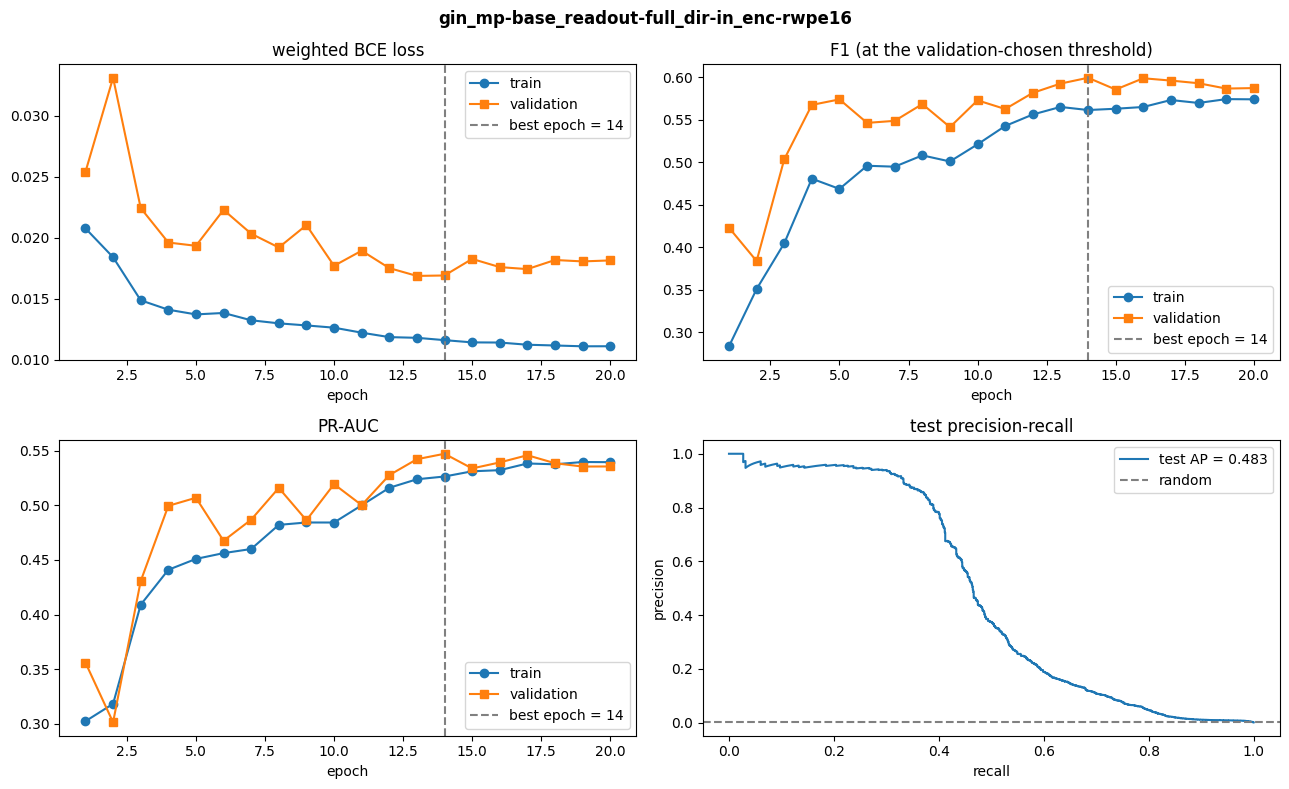

=== gin_mp-full_readout-full_dir-in_enc-rwpe16 ===
MP edge features: 81 | readout edge features: 81 | node features: 22
total params: 133,891 | architecture-invariant: 67,587


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0090 / 0.0236 | F1 0.6143 / 0.5817 @ 0.682 | PR-AUC 0.6200 / 0.5187 | 129s | RAM 11.5GB   (train / val)
best validation F1 0.5899 at epoch 16 (threshold 0.656)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.6101  0.5891  0.5006
precision          0.7556  0.8094  0.7584
recall             0.5115  0.4630  0.3736
pr_auc             0.6111  0.5294  0.4522
roc_auc            0.9941  0.9756  0.9662
precision_at_5pct  0.0145  0.0173  0.0178
recall_at_5pct     0.9626  0.8124  0.7918
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-full_readout-full_dir-in_enc-rwpe16/predictions.csv


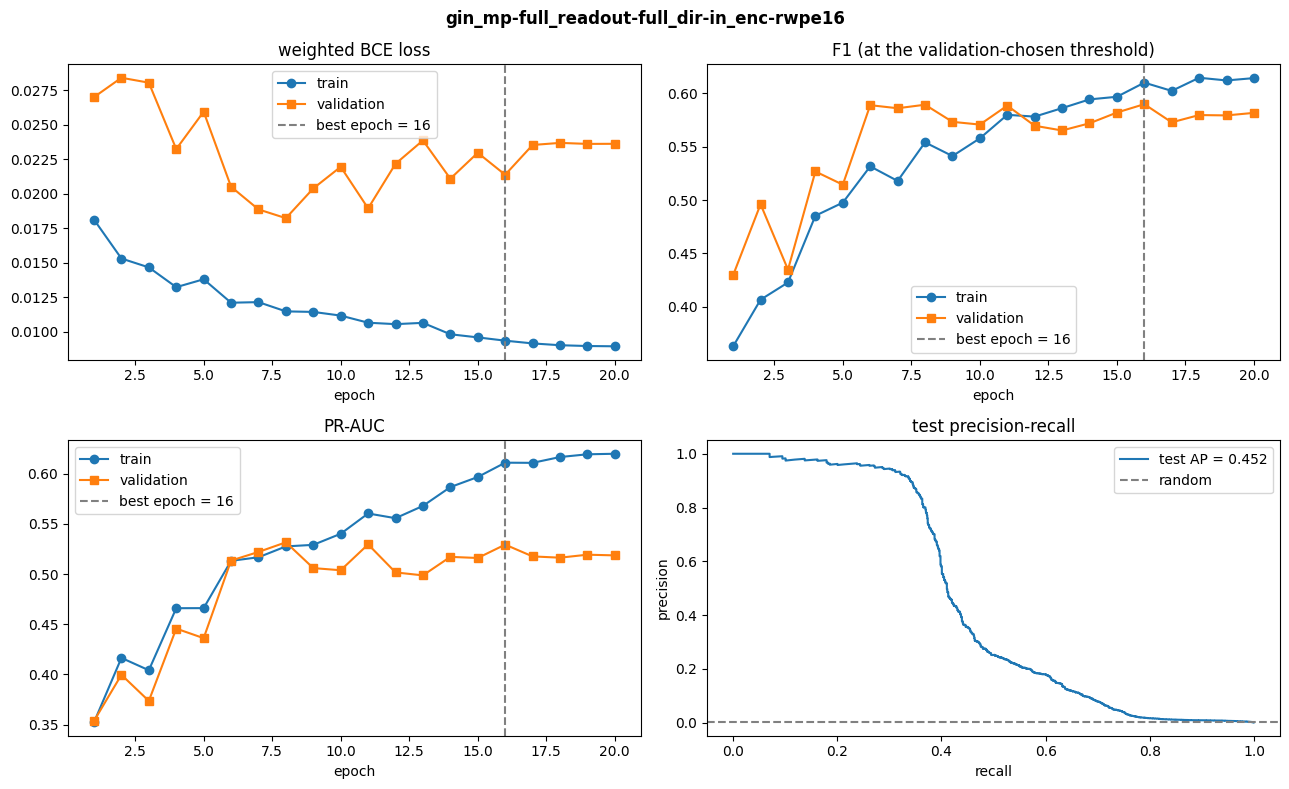

batch complete


In [6]:
rows = []
for cfg in CONFIGS:
    print('=' * 90)
    rows.append(core.run_experiment(cfg['operator'], cfg, graphs, col_sets, node_dim,
                                    f"{OUT_BASE}/{cfg['operator'].upper()}", MP_DIRECTION, TEMPORAL_SAMPLING,
                                    cfg['node_enc'], RWPE_DIR))
print('=' * 90)
print('batch complete')

## 5. Comparison across the batch

- `batch_summary_rwpe.csv` per operator holds every `<split>_<metric>` column plus `threshold`, `best_epoch`, `params`, `invariant_params`, `node_enc`.
- `invariant_params` must be identical in every row of an operator (asserted).

In [7]:
for operator in sorted({cfg['operator'] for cfg in CONFIGS}):
    summary = core.summarize_batch([row for row in rows if row['operator'] == operator],
                                   f'{OUT_BASE}/{operator.upper()}', 'batch_summary_rwpe.csv')
    display(summary[['node_enc'] + core.DISPLAY_COLS].round(4))

2 runs -> /kaggle/working/Outputs/GIN/batch_summary_rwpe.csv | invariant_params = 67,587 in every row


,node_enc,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,rwpe16,gin_mp-base_readout-full_dir-in_enc-rwpe16,14,0.6574,0.5995,0.5237,0.7238,0.4103,0.4832,0.0191,0.8504,118275,67587
1,rwpe16,gin_mp-full_readout-full_dir-in_enc-rwpe16,16,0.6561,0.5891,0.5006,0.7584,0.3736,0.4522,0.0178,0.7918,133891,67587


## 6. Download

- Zip `OUT_BASE`; extract into `Outputs/RWPE/` in the repo and commit the small result files (`best.pt` and `predictions.csv` stay out of git).

In [8]:
import shutil
shutil.make_archive('/kaggle/working/Outputs_RWPE', 'zip', OUT_BASE)

'/kaggle/working/Outputs_RWPE.zip'